In [1]:
import pandas as pd

df = pd.read_csv('heart_2020_cleaned.csv')
print("شکل دیتا:", df.shape)
df.head()

شکل دیتا: (319795, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# تبدیل متن به عدد
le = LabelEncoder()
df_encoded = df.copy()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

# جدا کردن ورودی و هدف
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# تقسیم train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# نرمال‌سازی
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("آماده شد!")
print("تعداد آموزش:", X_train.shape)
print("تعداد تست:", X_test.shape)

آماده شد!
تعداد آموزش: (255836, 17)
تعداد تست: (63959, 17)


In [3]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# اول SMOTE برای متوازن کردن دیتا
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# ساختن مدل Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)

print("مدل Random Forest آموزش دید!")

مدل Random Forest آموزش دید!


In [4]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("گزارش کامل Random Forest:")
print(classification_report(y_test, y_pred_rf))
print("AUC Score:", roc_auc_score(y_test, y_prob_rf))

گزارش کامل Random Forest:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     58367
           1       0.30      0.23      0.26      5592

    accuracy                           0.89     63959
   macro avg       0.61      0.59      0.60     63959
weighted avg       0.87      0.89      0.88     63959

AUC Score: 0.7902717467194225


In [5]:
rf_model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model2.fit(X_train_resampled, y_train_resampled)

y_pred_rf2 = rf_model2.predict(X_test_scaled)
y_prob_rf2 = rf_model2.predict_proba(X_test_scaled)[:, 1]

print("گزارش Random Forest با class_weight:")
print(classification_report(y_test, y_pred_rf2))
print("AUC Score:", roc_auc_score(y_test, y_prob_rf2))

گزارش Random Forest با class_weight:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     58367
           1       0.30      0.23      0.26      5592

    accuracy                           0.89     63959
   macro avg       0.61      0.59      0.60     63959
weighted avg       0.87      0.89      0.88     63959

AUC Score: 0.7902717497832582


In [6]:
y_pred_rf3 = (y_prob_rf > 0.3).astype(int)

print("گزارش Random Forest با threshold=0.3:")
print(classification_report(y_test, y_pred_rf3))

گزارش Random Forest با threshold=0.3:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91     58367
           1       0.27      0.46      0.34      5592

    accuracy                           0.84     63959
   macro avg       0.61      0.67      0.63     63959
weighted avg       0.89      0.84      0.86     63959



In [7]:
!pip install xgboost -q

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='auc'
)

xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("گزارش XGBoost:")
print(classification_report(y_test, y_pred_xgb))
print("AUC Score:", roc_auc_score(y_test, y_prob_xgb))

گزارش XGBoost:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     58367
           1       0.33      0.25      0.28      5592

    accuracy                           0.89     63959
   macro avg       0.63      0.60      0.61     63959
weighted avg       0.88      0.89      0.88     63959

AUC Score: 0.8180412363111194


In [8]:
y_pred_xgb_t = (y_prob_xgb > 0.3).astype(int)

print("گزارش XGBoost با threshold=0.3:")
print(classification_report(y_test, y_pred_xgb_t))

گزارش XGBoost با threshold=0.3:
              precision    recall  f1-score   support

           0       0.95      0.85      0.90     58367
           1       0.27      0.55      0.36      5592

    accuracy                           0.83     63959
   macro avg       0.61      0.70      0.63     63959
weighted avg       0.89      0.83      0.85     63959



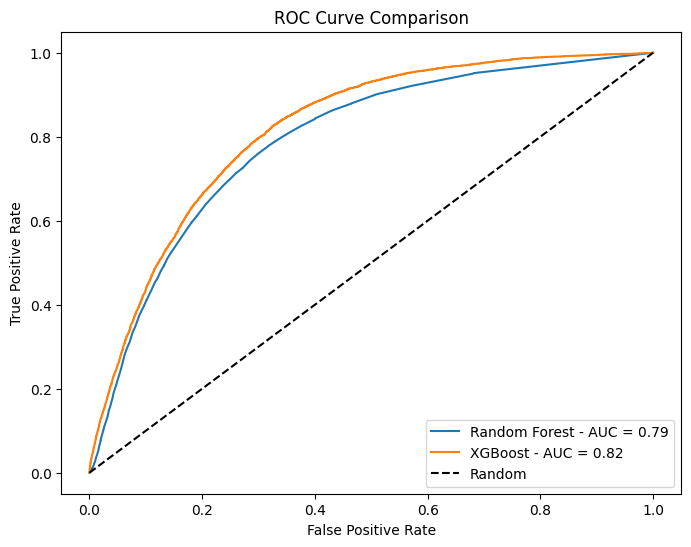

In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label='Random Forest - AUC = ' + str(round(auc_rf,2)))
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost - AUC = ' + str(round(auc_xgb,2)))
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

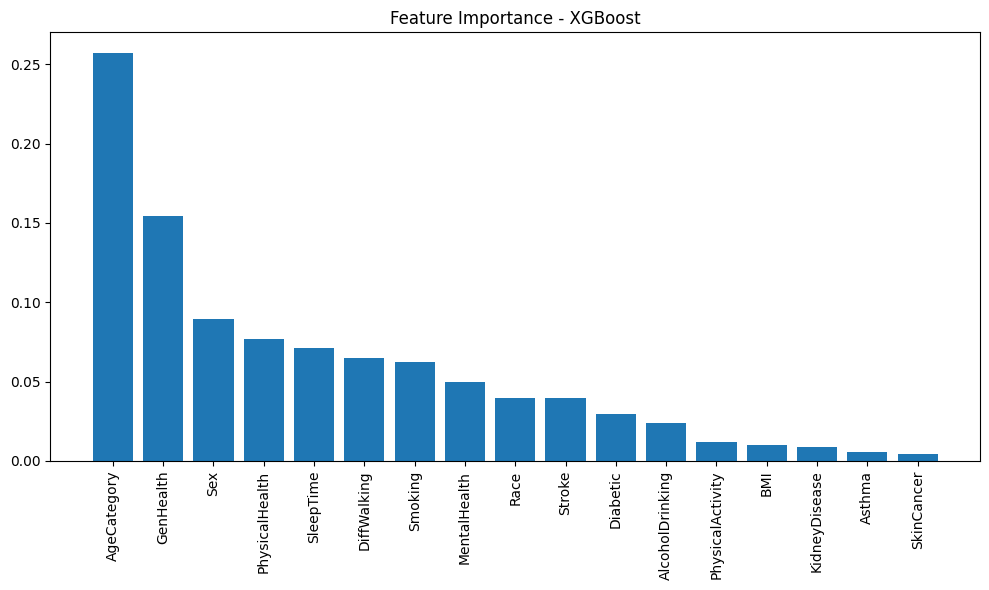

ترتیب اهمیت ویژگی‌ها:
AgeCategory: 0.2572
GenHealth: 0.1545
Sex: 0.0893
PhysicalHealth: 0.0770
SleepTime: 0.0712
DiffWalking: 0.0648
Smoking: 0.0620
MentalHealth: 0.0497
Race: 0.0399
Stroke: 0.0397
Diabetic: 0.0299
AlcoholDrinking: 0.0238
PhysicalActivity: 0.0121
BMI: 0.0099
KidneyDisease: 0.0089
Asthma: 0.0055
SkinCancer: 0.0046


In [12]:
import numpy as np

# اهمیت ویژگی‌ها از مدل XGBoost
importances = xgb_model.feature_importances_
feature_names = X.columns

# مرتب کردن از بیشترین به کمترین
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title('Feature Importance - XGBoost')
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

print("ترتیب اهمیت ویژگی‌ها:")
for i in indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

In [13]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("گزارش Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print("AUC Score:", roc_auc_score(y_test, y_prob_lr))

گزارش Logistic Regression:
              precision    recall  f1-score   support

           0       0.97      0.73      0.84     58367
           1       0.22      0.77      0.34      5592

    accuracy                           0.74     63959
   macro avg       0.59      0.75      0.59     63959
weighted avg       0.91      0.74      0.79     63959

AUC Score: 0.8256877260145603


In [14]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# تنظیم 5-fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# تست روی Logistic Regression
lr_scores = cross_val_score(lr_model, X_train_resampled, y_train_resampled, cv=cv, scoring='roc_auc')

# تست روی XGBoost
xgb_scores = cross_val_score(xgb_model, X_train_resampled, y_train_resampled, cv=cv, scoring='roc_auc')

print("Logistic Regression - AUC در 5 fold:", lr_scores)
print("میانگین:", lr_scores.mean(), "± انحراف معیار:", lr_scores.std())
print()
print("XGBoost - AUC در 5 fold:", xgb_scores)
print("میانگین:", xgb_scores.mean(), "± انحراف معیار:", xgb_scores.std())

Logistic Regression - AUC در 5 fold: [0.83452119 0.8346837  0.83428315 0.83316742 0.83341501]
میانگین: 0.8340140924623309 ± انحراف معیار: 0.0006088799360758687

XGBoost - AUC در 5 fold: [0.97537013 0.97536601 0.97473111 0.97505481 0.97473499]
میانگین: 0.9750514084249513 ± انحراف معیار: 0.0002839993128287705


In [15]:
from imblearn.pipeline import Pipeline as ImbPipeline

# ساخت pipeline درست: SMOTE فقط روی train هر fold اعمال میشه
pipeline_xgb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='auc'))
])

pipeline_lr = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# دوباره Cross-Validation با pipeline درست - این بار روی X_train اصلی (نه resampled)
xgb_scores_correct = cross_val_score(pipeline_xgb, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
lr_scores_correct = cross_val_score(pipeline_lr, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print("XGBoost (درست) - میانگین AUC:", xgb_scores_correct.mean(), "±", xgb_scores_correct.std())
print("Logistic Regression (درست) - میانگین AUC:", lr_scores_correct.mean(), "±", lr_scores_correct.std())

XGBoost (درست) - میانگین AUC: 0.8225823715311588 ± 0.0011201612992959705
Logistic Regression (درست) - میانگین AUC: 0.8279738626438411 ± 0.0007072012241444841
